In [2]:
!pip install git+https://github.com/openai/CLIP.git


  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-6b7lfqsf
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-6b7lfqsf
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 102.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 84.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 54.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
!pip install ftfy regex tqdm
!pip install scikit-learn

In [15]:
import clip
import torch
from PIL import Image
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Configurar dispositivo
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Usando dispositivo: {device}")

# Cargar modelo CLIP
model, preprocess = clip.load("ViT-B/32", device=device)


Usando dispositivo: cpu


In [16]:
# ⚙️ Configurar dispositivo (GPU si está disponible)
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)


In [17]:
from google.colab import files
uploaded = files.upload()


Saving carro1.jpg to carro1 (1).jpg
Saving carro2.jpg to carro2 (1).jpg
Saving carro3.jpg to carro3 (1).jpg
Saving frutas.jpg to frutas.jpg
Saving frutas1.jpg to frutas1.jpg
Saving frutas2.jpg to frutas2.jpg
Saving frutas3.png to frutas3.png
Saving gato1.jpg to gato1 (1).jpg
Saving gato2.jpg to gato2 (1).jpg
Saving gato3jpg.jpg to gato3jpg (1).jpg


In [18]:
# 🖼️ Preparar imágenes
image_paths = list(uploaded.keys())
images = [preprocess(Image.open(p)).unsqueeze(0).to(device) for p in image_paths]


In [19]:
# 🔍 Embeddings con CLIP
with torch.no_grad():
    image_features = [model.encode_image(img).cpu().numpy() for img in images]
X = np.vstack(image_features)

In [20]:
X_pca = PCA(n_components=2).fit_transform(X)
X_tsne = TSNE(n_components=2, perplexity=4).fit_transform(X)


In [21]:
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

def plot_embeddings(X_embedded, title):
    fig, ax = plt.subplots(figsize=(10, 8))
    plt.title(title)

    for i, path in enumerate(image_paths):
        img = Image.open(path)
        img = img.resize((32, 32))  # miniatura

        im = OffsetImage(img, zoom=1)  # ajustar tamaño
        ab = AnnotationBbox(im, (X_embedded[i, 0], X_embedded[i, 1]), frameon=False)
        ax.add_artist(ab)

    ax.set_xlim(X_embedded[:, 0].min() - 1, X_embedded[:, 0].max() + 1)
    ax.set_ylim(X_embedded[:, 1].min() - 1, X_embedded[:, 1].max() + 1)
    plt.grid(True)
    plt.show()



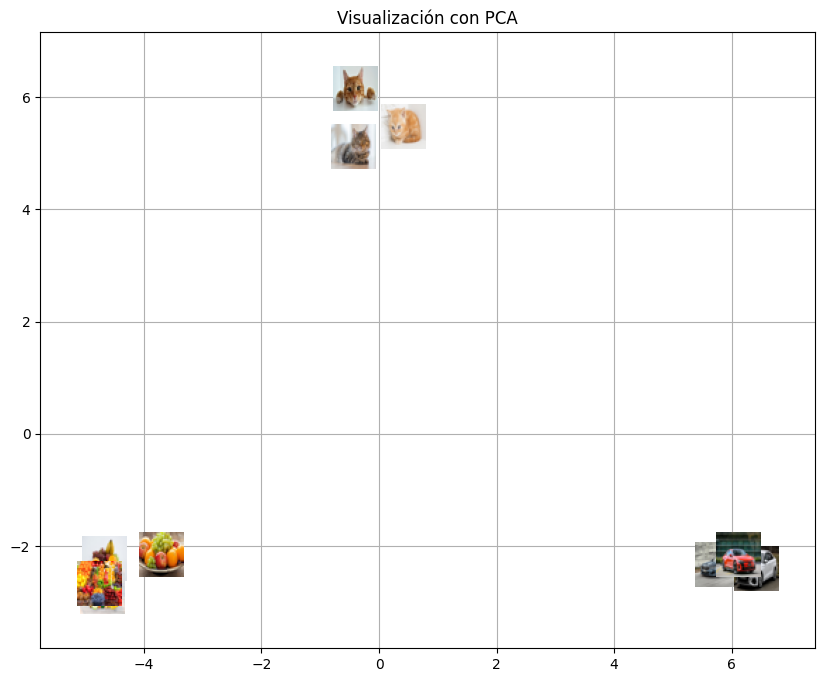

In [22]:
plot_embeddings(X_pca, "Visualización con PCA")
# plot_embeddings(X_tsne, "Visualización con t-SNE")
